# Spaceship Titanic — Preprocessing Pipeline
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Executing every Feature Engineering Decision from `spaceship_titanic_eda.ipynb` (Week 5) — building the final reusable preprocessing pipeline that Weeks 7–8 imports directly for model training.

### Main goals:

- Implement Cabin parsing, spending aggregation, and age binning.
- Build a ColumnTransformer pipeline with no data leakage.
- Verify the transformed feature matrix is clean and ready for modelling.
- Produce a preprocessing workflow Weeks 7–8 reuses without modification.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Load Train and Test Datasets

In [2]:
TRAIN_URL = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_train.csv'
TEST_URL  = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/spaceship_titanic_test.csv'

train_raw = pd.read_csv(TRAIN_URL)
test_raw  = pd.read_csv(TEST_URL)

print(f'Train shape: {train_raw.shape}')
print(f'Test shape:  {test_raw.shape}')
train_raw.head()

Train shape: (8693, 14)
Test shape:  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Step 1 — Cabin Parsing

Direct implementation of the three-line split practised in `feature_engineering_for_spaceship_titanic.ipynb`.

In [3]:
def parse_cabin(df):
    df = df.copy()
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck']     = cabin_split[0]
    df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
    df['Side']     = cabin_split[2]
    df = df.drop(columns=['Cabin'])
    return df

train = parse_cabin(train_raw)
test  = parse_cabin(test_raw)

print('Deck value counts (train):')
print(train['Deck'].value_counts())
print()
print('Side value counts (train):')
print(train['Side'].value_counts())

Deck value counts (train):
Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64

Side value counts (train):
Side
S    4288
P    4206
Name: count, dtype: int64


## Step 2 — Spending Features

Aggregation and interaction features identified in the Week 5 EDA.

In [4]:
SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

def add_spend_features(df):
    df = df.copy()
    df['TotalSpend'] = df[SPEND_COLS].fillna(0).sum(axis=1)
    df['IsSpender']  = (df['TotalSpend'] > 0).astype(int)
    return df

train = add_spend_features(train)
test  = add_spend_features(test)

print('TotalSpend stats (train):')
print(train['TotalSpend'].describe().round(2))
print(f'\nIsSpender rate: {train["IsSpender"].mean():.3f}')

TotalSpend stats (train):
count     8693.00
mean      1440.87
std       2803.05
min          0.00
25%          0.00
50%        716.00
75%       1441.00
max      35987.00
Name: TotalSpend, dtype: float64

IsSpender rate: 0.580


In [5]:
# Verify CryoSleep x IsSpender interaction from Week 5 EDA
ct = train.groupby('CryoSleep')['IsSpender'].mean()
print('IsSpender rate by CryoSleep:')
print(ct.round(4))

IsSpender rate by CryoSleep:
CryoSleep
False    0.9048
True     0.0000
Name: IsSpender, dtype: float64


**Observation:**
CryoSleep passengers have near-zero spending rates — confirming the interaction identified in `spaceship_titanic_eda.ipynb`. `IsSpender` explicitly encodes this without requiring the model to discover it from five separate spending columns.

## Step 3 — Age Groups

Binning identified in the Week 5 EDA: children transport at a higher rate.

In [6]:
AGE_BINS   = [0, 12, 17, 35, 60, 200]
AGE_LABELS = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']

def add_age_group(df):
    df = df.copy()
    df['AgeGroup'] = pd.cut(df['Age'], bins=AGE_BINS, labels=AGE_LABELS)
    df['AgeGroup'] = df['AgeGroup'].astype(str).replace('nan', np.nan)
    return df

train = add_age_group(train)
test  = add_age_group(test)

print('AgeGroup value counts (train):')
print(train['AgeGroup'].value_counts())

AgeGroup value counts (train):
AgeGroup
YoungAdult    4456
Adult         2293
Teen           739
Child          628
Senior         220
Name: count, dtype: int64


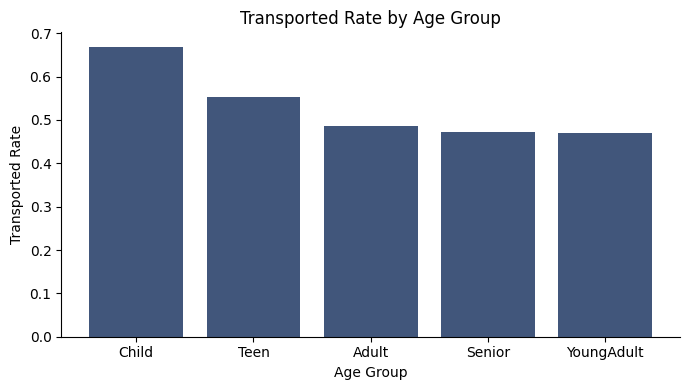

In [7]:
# Verify transport rate by AgeGroup
age_transport = train.groupby('AgeGroup', observed=False)['Transported'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(age_transport.index, age_transport.values, color='#1F3864', alpha=0.85)
ax.set_xlabel('Age Group')
ax.set_ylabel('Transported Rate')
ax.set_title('Transported Rate by Age Group')
plt.tight_layout()
plt.show()

**Observation:**
Children show a notably higher transported rate, validating the `AgeGroup` feature. The binned feature captures this step-wise pattern more directly than the raw continuous `Age` value for linear models.

## Step 4 — Drop Uninformative Columns

In [8]:
DROP_COLS = ['PassengerId', 'Name']

def drop_cols(df):
    return df.drop(columns=[c for c in DROP_COLS if c in df.columns])

train = drop_cols(train)
test  = drop_cols(test)

print('Remaining columns:')
print(train.columns.tolist())

Remaining columns:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Deck', 'CabinNum', 'Side', 'TotalSpend', 'IsSpender', 'AgeGroup']


## Step 5 — Define Feature Sets

In [9]:
TARGET = 'Transported'

NUMERIC_COLS = [
    'Age', 'CabinNum',
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
    'TotalSpend', 'IsSpender'
]

CATEGORICAL_COLS = [
    'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
    'Deck', 'Side', 'AgeGroup'
]

FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS

X_train = train[FEATURE_COLS]
y_train = train[TARGET].astype(int)
X_test  = test[FEATURE_COLS]

print(f'Features: {len(FEATURE_COLS)}  |  Numeric: {len(NUMERIC_COLS)}  |  Categorical: {len(CATEGORICAL_COLS)}')
print(f'Train samples: {len(X_train)}  |  Test samples: {len(X_test)}')

Features: 16  |  Numeric: 9  |  Categorical: 7
Train samples: 8693  |  Test samples: 4277


## Step 6 — ColumnTransformer Pipeline

Exact structure from `machine_learning_pipelines.ipynb` — numeric path applies log1p before scaling to address the right-skew observed in Week 5.

In [10]:
from sklearn.preprocessing import FunctionTransformer

log1p_transformer = FunctionTransformer(np.log1p, validate=False)

# Separate spend cols (need log1p) from other numeric cols
SPEND_AND_TOTAL = SPEND_COLS + ['TotalSpend']
OTHER_NUMERIC   = [c for c in NUMERIC_COLS if c not in SPEND_AND_TOTAL]

spend_transformer = Pipeline([
    ('imputer',  SimpleImputer(strategy='median')),
    ('log1p',    log1p_transformer),
    ('scaler',   StandardScaler())
])

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('spend',  spend_transformer,       SPEND_AND_TOTAL),
    ('num',    numeric_transformer,     OTHER_NUMERIC),
    ('cat',    categorical_transformer, CATEGORICAL_COLS)
], remainder='drop')

print('Preprocessor defined.')

Preprocessor defined.


## Step 7 — Fit on Train Only (No Leakage)

In [11]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

# Fit ONLY on training fold — never on validation or test
preprocessor.fit(X_tr)

X_tr_t  = preprocessor.transform(X_tr)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

print(f'X_tr_t shape:   {X_tr_t.shape}')
print(f'X_val_t shape:  {X_val_t.shape}')
print(f'X_test_t shape: {X_test_t.shape}')

X_tr_t shape:   (7389, 34)
X_val_t shape:  (1304, 34)
X_test_t shape: (4277, 34)


## Step 8 — Verify Output Quality

In [12]:
print("=== Missing Values After Transform ===")
print(f'Train:  {np.isnan(X_tr_t).sum()} NaNs')
print(f'Val:    {np.isnan(X_val_t).sum()} NaNs')
print(f'Test:   {np.isnan(X_test_t).sum()} NaNs')

print()
print('=== Train Feature Stats (first 5 cols) ===')
stats = pd.DataFrame(X_tr_t[:, :5]).describe().round(3)
print(stats)

=== Missing Values After Transform ===
Train:  0 NaNs
Val:    0 NaNs
Test:   0 NaNs

=== Train Feature Stats (first 5 cols) ===
              0         1         2         3         4
count  7389.000  7389.000  7389.000  7389.000  7389.000
mean      0.000    -0.000     0.000    -0.000    -0.000
std       1.000     1.000     1.000     1.000     1.000
min      -0.641    -0.646    -0.618    -0.660    -0.641
25%      -0.641    -0.646    -0.618    -0.660    -0.641
50%      -0.641    -0.646    -0.618    -0.660    -0.641
75%       0.745     0.745     0.573     0.765     0.712
max       2.865     2.870     3.064     2.971     2.973


In [13]:
# Target class balance
print('Target distribution (full train):')
print(y_train.value_counts())
print(f'Positive rate: {y_train.mean():.4f}')

# Get feature names from the fitted preprocessor
ohe_cats = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(CATEGORICAL_COLS)
feature_names = SPEND_AND_TOTAL + OTHER_NUMERIC + list(ohe_cats)
print(f'\nTotal features after preprocessing: {len(feature_names)}')
print('Sample feature names:')
print(feature_names[:10])

Target distribution (full train):
Transported
1    4378
0    4315
Name: count, dtype: int64
Positive rate: 0.5036

Total features after preprocessing: 34
Sample feature names:
['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'Age', 'CabinNum', 'IsSpender', 'HomePlanet_Earth']


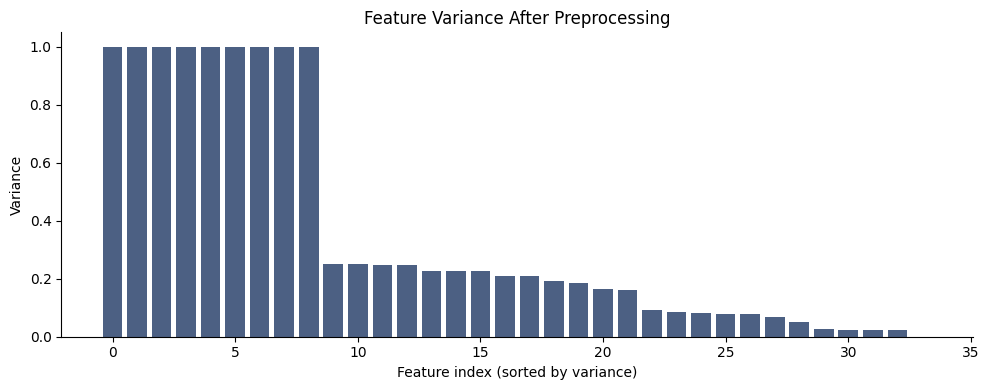

In [14]:
# Visualise feature variance — low-variance features add noise
variances = X_tr_t.var(axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(variances)), sorted(variances, reverse=True), color='#1F3864', alpha=0.8)
ax.set_xlabel('Feature index (sorted by variance)')
ax.set_ylabel('Variance')
ax.set_title('Feature Variance After Preprocessing')
plt.tight_layout()
plt.show()

**Observation:**
All features have non-trivial variance after preprocessing — no zero-variance columns that would need to be dropped. The scaled numeric features have mean ~0 and std ~1; the one-hot encoded categoricals have variance proportional to their class frequency.

## Preprocessing Summary

The pipeline built in this notebook is the direct input to all Weeks 7–8 model training. The following objects are used without modification in Weeks 7–8:

| Object | Used for |
|---|---|
| `preprocessor` | Fit on `X_tr`, transform `X_tr`, `X_val`, `X_test` |
| `X_tr_t`, `y_tr` | Training data for all Weeks 7–8 models |
| `X_val_t`, `y_val` | Validation data during Weeks 7–8 Keras training |
| `X_test_t` | Final test features for Kaggle submission |
| `feature_names` | Feature importance plots in Weeks 7–8 |

No data leakage: `preprocessor` was fit only on `X_tr` — validation and test folds were transformed using statistics from training data only.